In [12]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from pathlib import Path

In [2]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.99
batch_size = 64
learning_rate = 1e-3
num_seconds= 600
episodes = 100

In [25]:
# Initialize raw PettingZoo environment
env = sumo_rl.parallel_env(
    net_file="Intelligent-Traffic-Signal-Control-using-Reinforcement-Learning/dqn/env_iiser/map.net.xml",
    route_file="Intelligent-Traffic-Signal-Control-using-Reinforcement-Learning/dqn/env_iiser/routes.rou.alt.xml",
    use_gui=True, # Keep False for training
    num_seconds=num_seconds,
    delta_time=5,
    reward_fn="pressure",
)

FatalTraCIError: Connection closed by SUMO.

In [16]:
# Get dimensions for the network
sample_agent = env.possible_agents[0]
obs_dim = env.observation_space(sample_agent).shape[0]
action_dim = env.action_space(sample_agent).n

NameError: name 'env' is not defined

In [5]:
print(obs_dim)
print(action_dim)

9
2


In [6]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [7]:
# Initialize Dictionaries for Networks, Optimizers, and Buffers
q_nets = {}
optimizers = {}
replay_buffers = {}
loss_fn = nn.MSELoss()

for agent in env.possible_agents:
    obs_dim = env.observation_space(agent).shape[0]
    action_dim = env.action_space(agent).n
    
    q_nets[agent] = QNetwork(obs_dim, action_dim)
    optimizers[agent] = optim.Adam(q_nets[agent].parameters(), lr=learning_rate)
    replay_buffers[agent] = deque(maxlen=10000)

In [ ]:
all_episode_rewards = []

for episode in range(episodes):
    observations, infos = env.reset()
    episode_reward = 0
    
    while env.agents:
        actions = {}
        
        # Epsilon-Greedy Action Selection
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            if random.random() < epsilon:
                # Explore
                actions[agent] = env.action_space(agent).sample()
            else:
                # Exploit
                with torch.no_grad():
                    q_values = q_nets[agent](obs_tensor)
                    actions[agent] = torch.argmax(q_values).item()

        # Step the Environment 
        next_observations, rewards, terminations, truncations, infos = env.step(actions)

        # Store Transitions
        for agent in env.agents:
            replay_buffers[agent].append((
                observations[agent], 
                actions[agent], 
                rewards[agent], 
                next_observations[agent], 
                terminations[agent] or truncations[agent]
            ))
            episode_reward += rewards[agent]

            # Train the specific agent's Q-Network
            if len(replay_buffers[agent]) > batch_size:
                batch = random.sample(replay_buffers[agent], batch_size)
                b_obs, b_act, b_rew, b_next_obs, b_done = zip(*batch)
                
                b_obs = torch.FloatTensor(np.array(b_obs))
                b_act = torch.LongTensor(b_act).unsqueeze(1)
                b_rew = torch.FloatTensor(b_rew).unsqueeze(1)
                b_next_obs = torch.FloatTensor(np.array(b_next_obs))
                b_done = torch.FloatTensor(b_done).unsqueeze(1)

                current_q = q_nets[agent](b_obs).gather(1, b_act)
                
                with torch.no_grad():
                    max_next_q = q_nets[agent](b_next_obs).max(1)[0].unsqueeze(1)
                    target_q = b_rew + (gamma * max_next_q * (1 - b_done))
                
                loss = loss_fn(current_q, target_q)
                optimizers[agent].zero_grad()
                loss.backward()
                optimizers[agent].step()

        observations = next_observations

    all_episode_rewards.append(episode_reward)

    # Decay Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode + 1} | Total Shared Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

env.close()

In [14]:
for agent in env.possible_agents:
    model_path = f"./models/iiser/{agent}.pth"
    torch.save(q_nets[agent].state_dict(), model_path)

In [15]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    
    plt.plot(rewards, label='Episode Reward', color='dodgerblue', alpha=0.75)
    
    plt.title('Independent DQN Training')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig('training_curve.png')
    plt.show()

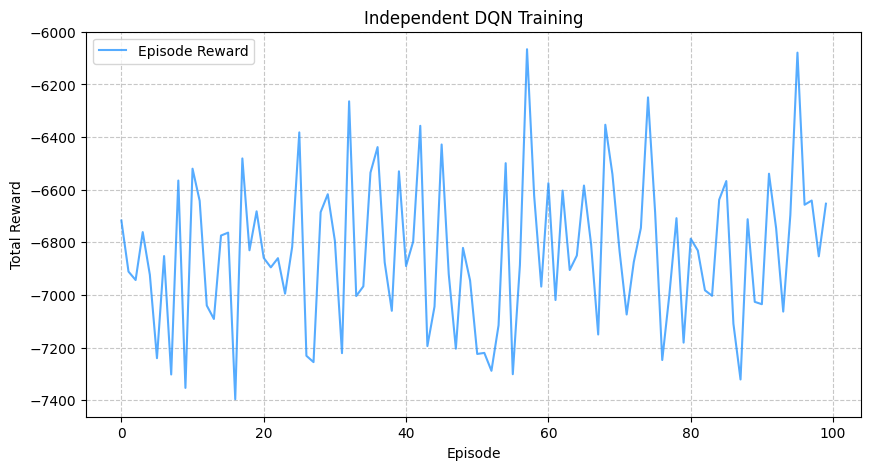

In [16]:
plot_rewards(all_episode_rewards)

In [21]:
def evaluate_model():
    env = sumo_rl.parallel_env(
        net_file="./env/map.net.xml",
        route_file="./env/routes.rou.xml",
        use_gui=True,
        num_seconds=600,   
        delta_time=5,
        reward_fn="pressure"
    )

    # Re-initialize and load models for each agent
    eval_q_nets = {}
    for agent in env.possible_agents:
        obs_dim = env.observation_space(agent).shape[0]
        action_dim = env.action_space(agent).n
        eval_q_nets[agent] = QNetwork(obs_dim, action_dim)
        
        try:
            eval_q_nets[agent].load_state_dict(torch.load(f"./models/iiser/{agent}.pth"))
            eval_q_nets[agent].eval()
        except FileNotFoundError:
            print(f"Error: Could not find the model for {agent}.")
            return

    print("Models loaded successfully!")

    # Run the Simulation Loop
    observations, infos = env.reset()
    total_evaluation_reward = 0
    
    while env.agents:
        actions = {}
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            with torch.no_grad():
                q_values = eval_q_nets[agent](obs_tensor)
                actions[agent] = torch.argmax(q_values).item() 

        observations, rewards, terminations, truncations, infos = env.step(actions)

        for agent in env.agents:
            total_evaluation_reward += rewards[agent]

    print(f"Simulation Finished. Final Total Reward: {total_evaluation_reward:.2f}")
    env.close()

In [22]:
evaluate_model()

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 67ms, vehicles TOT 0 ACT 0 BUF 0)                     
Models loaded successfully!
 Retrying in 1 seconds
Simulation Finished. Final Total Reward: -7763.00


In [23]:
env.close()